In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
import seaborn as sns

In [3]:
df=pd.read_csv('38_train (1).csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [7]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']

In [8]:
x_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [9]:
x_train[x_train['Age_imputed'].isnull()]

,Age,Fare,Age_imputed
77,NaN,8.0500,NaN
868,NaN,9.5000,NaN
334,NaN,133.6500,NaN
295,NaN,27.7208,NaN
792,NaN,69.5500,NaN
...,...,...,...
674,NaN,0.0000,NaN
466,NaN,0.0000,NaN
584,NaN,8.7125,NaN
527,NaN,221.7792,NaN


In [10]:
x_train['Age_imputed'][x_train['Age_imputed'].isnull()]

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [11]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([ 2.  , 14.  , 38.  , 30.  , 24.  , 20.  , 62.  , 30.  , 48.  ,
       40.  , 31.  , 14.  , 24.  , 40.  , 26.  , 28.  , 15.  , 41.  ,
       24.  , 42.  , 36.  , 36.  , 39.  , 26.  , 42.  , 21.  , 35.  ,
       19.  , 30.  , 31.  , 36.  ,  3.  , 15.  , 43.  , 21.  , 30.  ,
       45.  , 20.  , 54.  , 27.  , 19.  ,  9.  , 23.  , 32.  , 25.  ,
       24.  , 31.  , 14.5 , 31.  , 28.  , 34.  , 22.  , 22.  , 17.  ,
       22.  , 50.  , 31.  , 50.  , 16.  , 35.  , 60.  , 51.  , 29.  ,
       36.  , 47.  , 31.  , 23.  , 26.  , 20.  , 30.  , 24.  , 35.  ,
       54.  , 71.  , 16.  , 27.  , 24.  ,  1.  , 21.  , 70.5 , 24.  ,
       27.  , 29.  , 61.  , 18.  , 20.  , 18.  , 22.  , 36.  , 19.  ,
       24.  , 34.  , 25.  , 40.  , 20.  , 44.  ,  3.  , 25.  ,  9.  ,
       60.  , 18.  , 30.  , 20.  , 71.  , 23.  , 32.  , 19.  , 16.  ,
       25.  , 22.  , 50.  ,  4.  , 32.5 ,  0.67, 36.  , 14.  , 38.  ,
       30.  ,  1.  , 22.  , 25.  , 45.  , 16.  , 50.  , 24.  , 45.  ,
       26.  , 31.  ,

In [12]:
x_train['Age_imputed'][x_train['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['Age_imputed'][x_test['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_test['Age'].isnull().sum()).values


C:\Users\niraj\AppData\Local\Temp\ipykernel_129584\3089800503.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
C:

In [13]:
x_train['Age'].isnull().sum(),x_train['Age_imputed'].isnull().sum()

(148, 0)

In [14]:
x_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,28.0
493,71.0,49.5042,71.0
527,NaN,221.7792,43.0


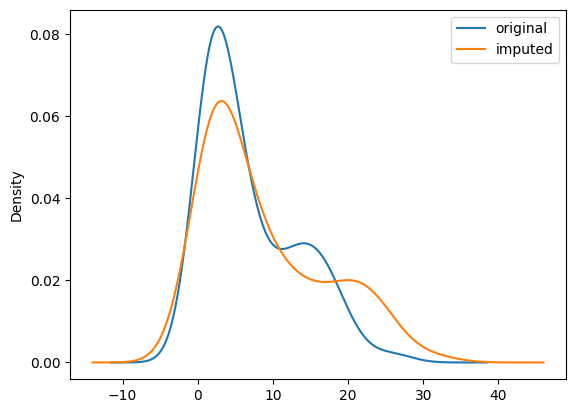

In [15]:
x_train['Age'].value_counts().plot.density(label='original')
x_train['Age_imputed'].value_counts().plot.density(label='imputed')
plt.legend()

C:\Users\niraj\AppData\Local\Temp\ipykernel_129584\2834876443.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label='original',kde=True)
C:\Users\niraj\AppData\Local\Temp\ipykernel_129584\2834876443.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age_imputed'],lab

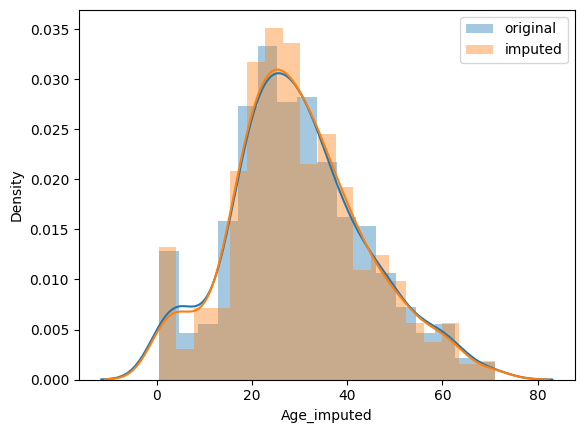

In [16]:
sns.distplot(x_train['Age'],label='original',kde=True)
sns.distplot(x_train['Age_imputed'],label='imputed',kde=True)
plt.legend()

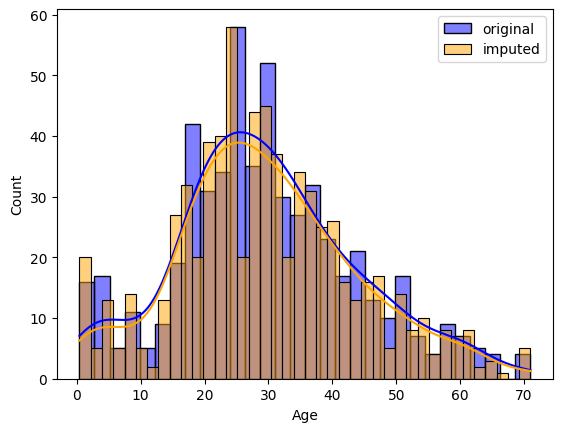

In [17]:
sns.histplot(x_train['Age'], label='original', kde=True, color='blue',bins=30)

# Plot the imputed 'Age_imputed' column
sns.histplot(x_train['Age_imputed'], label='imputed', kde=True, color='orange',bins=40)

# Add a legend
plt.legend()

In [18]:
print("original variable variance ",x_train['Age'].var())
print("Variance after random imputation : ",x_train['Age_imputed'].var())

original variable variance  204.34951339046142
Variance after random imputation :  198.0508878356169


In [19]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,64.031356
Age,71.512440,204.349513,204.349513
Age_imputed,64.031356,204.349513,198.050888


<Axes: >

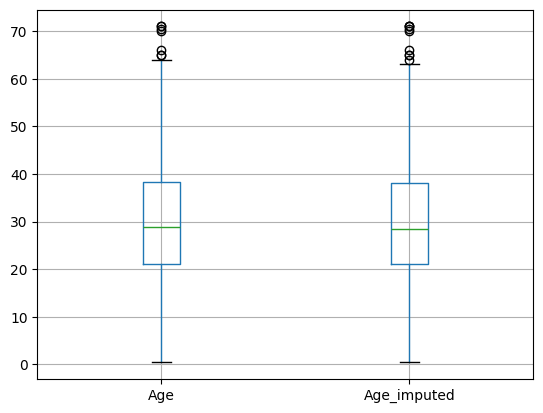

In [22]:
x_train[['Age','Age_imputed']].boxplot()

In [26]:
sampled_value = x_train['Age'].dropna().sample(1, random_state=int(x_train['Fare']))


TypeError: cannot convert the series to <class 'int'>

In [39]:
data=pd.read_csv("38_house-train.csv",usecols=['GarageQual','FireplaceQu','SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [40]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [41]:
x=data
y=data['SalePrice']

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [43]:
x_train['GarageQual_Imp']=x_train['GarageQual']
x_test['GarageQual_Imp']=x_test['GarageQual']

x_train['FireplaceQu_Imp']=x_train['FireplaceQu']
x_test['FireplaceQu_Imp']=x_test['FireplaceQu']

In [44]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_Imp,FireplaceQu_Imp
8,TA,Fa,129900,Fa,TA
645,NaN,TA,143250,TA,NaN
506,TA,TA,215000,TA,TA
1448,NaN,Fa,112000,Fa,NaN
1346,Gd,Gd,262500,Gd,Gd


In [48]:
x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

array(['TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'Fa', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA'], dtype=object)

In [55]:
x_train['GarageQual_Imp'][x_train['GarageQual_Imp'].isnull()]=x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_Imp'][x_test['GarageQual_Imp'].isnull()]=x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_Imp'][x_train['FireplaceQu_Imp'].isnull()]=x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_Imp'][x_test['FireplaceQu_Imp'].isnull()]=x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

C:\Users\niraj\AppData\Local\Temp\ipykernel_129584\1613245517.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_Imp'][x_train['GarageQual_Imp'].isnull()]=x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnul

In [56]:
temp=pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_Imp'].value_counts()/len(x_train)
    ],axis=1
)

temp.columns=['original','imputed']

In [57]:
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [58]:
temp=pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_Imp'].value_counts()/len(x_train)
    ],axis=1
)
temp

,count,count
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [61]:
temp=pd.concat(
    [
        x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_Imp'].value_counts()/len(x_train)
    ],axis=1
)

temp.columns=['original','imputed']
temp

,original,imputed
Gd,0.494272,0.500856
TA,0.412439,0.404110
Fa,0.040917,0.042808
Po,0.027823,0.028253
Ex,0.024550,0.023973


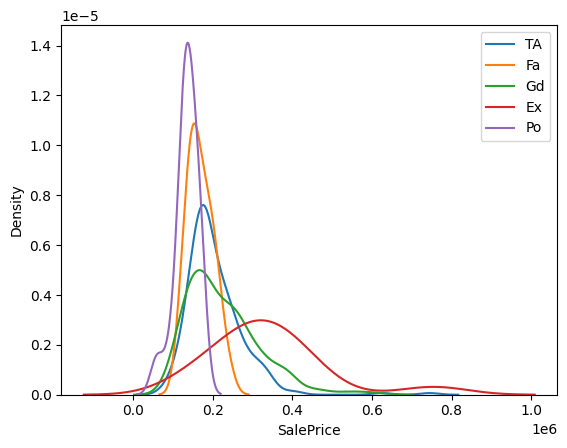

In [67]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()

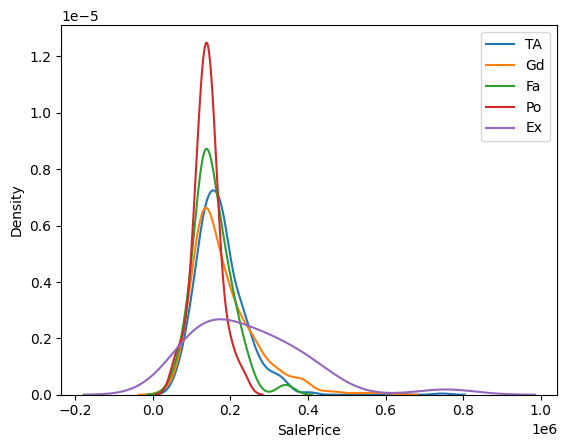

In [68]:
for category in x_train['FireplaceQu_Imp'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu_Imp'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()

                      Missing Indicator

In [121]:
from sklearn.impute import MissingIndicator,SimpleImputer

In [122]:
df=pd.read_csv("38_train (1).csv",usecols=['Age','Fare','Survived'])

In [123]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [124]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [125]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [126]:
x_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [127]:
si=SimpleImputer()
x_train_tf=si.fit_transform(x_train)
x_test_trf=si.transform(x_test)

In [128]:
x_train_tf

array([[ 40.        ,  27.7208    ],
       [  4.        ,  16.7       ],
       [ 47.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ],
       [ 29.78590426, 221.7792    ],
       [ 29.78590426,  25.925     ]])

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
clf=LogisticRegression()
clf.fit(x_train_tf,y_train)
y_pred=clf.predict(x_test_trf)
accuracy_score(y_test,y_pred)

0.6145251396648045

In [130]:
mi=MissingIndicator()
mi.fit(x_train)

MissingIndicator()

In [131]:
mi.features

'missing-only'

In [134]:
x_train_missing=mi.transform(x_train)
x_test_missing=mi.transform(x_test)

In [135]:
x_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [136]:
x_train['Age_NA']=x_train_missing

In [137]:
x_test['Age_NA']=x_test_missing

In [138]:
x_train

,Age,Fare,Age_NA
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [139]:
x_test

,Age,Fare,Age_NA
707,42.0,26.2875,False
37,21.0,8.0500,False
615,24.0,65.0000,False
169,28.0,56.4958,False
68,17.0,7.9250,False
...,...,...,...
89,24.0,8.0500,False
80,22.0,9.0000,False
846,NaN,69.5500,True
870,26.0,7.8958,False


In [140]:
si=SimpleImputer()
x_train_tf2=si.fit_transform(x_train)
x_test_tf2=si.transform(x_test)

In [141]:
clf=LogisticRegression()
clf.fit(x_train_tf2,y_train)
y_pred=clf.predict(x_test_tf2)
accuracy_score(y_pred,y_test)

0.6312849162011173

Using SimpleImputer for missing indicator

In [142]:
si=SimpleImputer(add_indicator=True)

In [146]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [151]:
x_train.shape

(712, 3)

In [147]:
x_train=si.fit_transform(x_train)

In [148]:
x_test=si.transform(x_test)

In [152]:
clf=LogisticRegression()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.6312849162011173

                  GridSecrch CV

In [176]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [177]:
df=pd.read_csv("38_train (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [178]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [179]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [180]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [181]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [182]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [183]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [184]:
numerical_feature=['Age','Fare']
numerical_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)
categorical_feature=['Embarked','Sex']
categorical_transformer=Pipeline(
    steps=
        [
            ('imputer',SimpleImputer(strategy='most_frequent')),
            ('ohe',OneHotEncoder(handle_unknown='ignore'))
        ]
)

In [185]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical_feature),
        ('cat',categorical_transformer,categorical_feature)
    ]
)

In [186]:
clf=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

In [187]:
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Embarked', 'Sex'])])),
                ('classifier', LogisticRegression())])

In [222]:
param_grid = {
    'preprocessor__num__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],  # Adjusting the nested imputer's parameter
    'classifier__C': [0.1, 1, 10]  # Example of a parameter for LogisticRegression
}


In [223]:
grid_search=GridSearchCV(clf,param_grid,cv=10)

In [224]:
grid_search.fit(x_train,y_train)

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(),
                                                                         ['Age',
                                                                          'Fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Embarked',
                                                                          'Sex'])])),
                                       ('classifier', LogisticRegression())]),
             param_grid={'classifier__C': [0.1, 1, 10],
                         'preprocessor__cat__imputer__strategy': ['most_frequent',
                                                                  'constant'],
                         'preprocessor__num__strategy': ['mean', 'median']})

In [225]:
grid_search.best_params_

{'classifier__C': 1,
 'preprocessor__cat__imputer__strategy': 'most_frequent',
 'preprocessor__num__strategy': 'mean'}

In [226]:
cv_results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_classifier__C', 'param_preprocessor__cat__imputer__strategy',
       'param_preprocessor__num__strategy', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'split5_test_score', 'split6_test_score',
       'split7_test_score', 'split8_test_score', 'split9_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score'],
      dtype='object')

In [227]:
cv_results=pd.DataFrame(grid_search.cv_results_)
cv_results.sort_values('mean_test_score',ascending=False)
cv_results[[
       'param_classifier__C', 'param_preprocessor__cat__imputer__strategy',
       'param_preprocessor__num__strategy', 'params',
       'mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__strategy,params,mean_test_score
0,0.1,most_frequent,mean,"{'classifier__C': 0.1, 'preprocessor__cat__imp...",0.785035
1,0.1,most_frequent,median,"{'classifier__C': 0.1, 'preprocessor__cat__imp...",0.785035
2,0.1,constant,mean,"{'classifier__C': 0.1, 'preprocessor__cat__imp...",0.785035
3,0.1,constant,median,"{'classifier__C': 0.1, 'preprocessor__cat__imp...",0.785035
4,1.0,most_frequent,mean,"{'classifier__C': 1, 'preprocessor__cat__imput...",0.787852
5,1.0,most_frequent,median,"{'classifier__C': 1, 'preprocessor__cat__imput...",0.787852
6,1.0,constant,mean,"{'classifier__C': 1, 'preprocessor__cat__imput...",0.787852
7,1.0,constant,median,"{'classifier__C': 1, 'preprocessor__cat__imput...",0.787852
8,10.0,most_frequent,mean,"{'classifier__C': 10, 'preprocessor__cat__impu...",0.787852
9,10.0,most_frequent,median,"{'classifier__C': 10, 'preprocessor__cat__impu...",0.787852
